# Helmholtz resonance in the transient regime -- open neck, meshed exterior

**Summary.** The resonator is simulated with its neck **genuinely open** onto a **meshed**
exterior half-space (flat baffle), and excited by a **broadband pulse**. The full sequence is
observed: the wave propagates, enters through the neck, the cavity fills -- and then, once the
pulse has gone, **the cavity keeps ringing at its own natural frequency**. This is Helmholtz
resonance, obtained without imposing any frequency.

Two verifiable results come out of it:

| Quantity | Measured | Reference | Deviation |
|---|---|---|---|
| $f_0$, extrapolated to zero mesh size | **204.6 Hz** (GCI 1.5 %) | Helmholtz with end corrections: 205.6 Hz | **0.47 %** |
| $Q$ from the envelope decay | **not measurable here** | varies by a factor of 6 with the boundary treatment | numerical artefact |

> This notebook carries out the **first perspective** announced in the project README: a *meshed
> exterior domain for an ab initio account of radiation*. The exterior end correction is no
> longer **postulated** -- it is **computed** by the mesh.


## 1. Why the neck has to be open: a sealed box is not a resonator

If every wall is rigid, the neck entrance included, the geometry is a **sealed box**. A sealed box
has **no** Helmholtz resonance: its first acoustic mode sits near 1400 Hz, well above the band of
interest. Its response is **stiffness-controlled** and reduces to a **pressure ramp** -- the
uniform mode, $\frac{d^2}{dt^2}\langle p\rangle=\langle F\rangle$.

Helmholtz resonance requires an **open neck**: the plug of air in the neck (the mass) oscillates
against the air in the cavity (the spring). That is what is set up here.

| | sealed box | **this notebook** |
|---|---|---|
| Neck | closed (rigid wall) | **open** onto a meshed exterior |
| Physics | uniform mode, a **ramp** | mass-spring **resonance** |
| Response | monotonic, a few Pa | sustained oscillation at $f_0$ |


In [1]:
%matplotlib inline
# run from the repository root wherever the notebook is opened from
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
d = np.load('data/open_resonator.npz')
r, z, dom = d['r'], d['z'], d['dom']
t, p_cav, p_out, p_neck = d['t'], d['p_cav'], d['p_out'], d['p_neck']
freqs, spec = d['freqs'], d['spec']
f0, f0_noc, f0_cor, Q = float(d['f0_meas']), float(d['f0_noc']), float(d['f0_cor']), float(d['Q_meas'])
# the solver has used both names for the stored field snapshots
snaps = d['snaps'] if 'snaps' in d.files else d['frames']
snap_t = d['snap_t'] if 'snap_t' in d.files else d['frame_t']

R_NECK, R_CAV, L_NECK, H_CAV, C = 0.01, 0.04, 0.04, 0.08, 343.0
print(f"domain: {dom.sum()} active cells, h = {float(d['H'])*1e3:.1f} mm, "
      f"dt = {float(d['dt'])*1e6:.2f} us, T = {float(d['T_MAX'])*1e3:.0f} ms")
print(f"wavelength at f0: {C/f0*100:.0f} cm  (resonator: 12 cm)  -> deeply SUB-WAVELENGTH")


domain: 15861 active cells, h = 1.0 mm, dt = 1.03 us, T = 250 ms
wavelength at f0: 164 cm  (resonator: 12 cm)  -> deeply SUB-WAVELENGTH


## 2. Configuration

Axisymmetric geometry $(r,z)$: a cavity ($r\le4$ cm, $4\le z\le12$ cm) on a neck ($r\le1$ cm,
$0\le z\le4$ cm), with an **open mouth at $z=0$**, a **rigid baffle** at $z=0$ for
$r>R_{\text{neck}}$, and a **meshed exterior** $-10\le z\le0$ cm terminated by **absorbing
layers**.

Scheme: explicit leapfrog in time; axisymmetric Laplacian in masked finite volumes, where zero
flux towards an out-of-domain cell gives an exact Neumann condition -- the baffle and the
neck/cavity step included. Excitation: a **Ricker pulse**, broadband and centred at 250 Hz,
emitted by a small source placed in the exterior. *No frequency is imposed on the resonator.*

*(Full code: `src/transient_solver.py`.)*


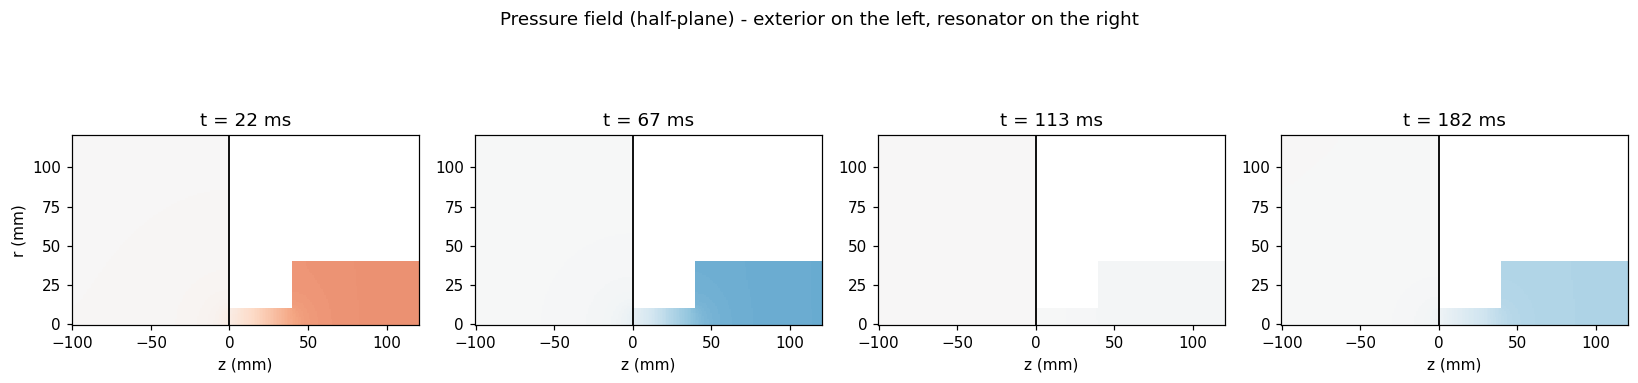

In [2]:
# Field snapshots: propagation, entry through the neck, build-up of the resonance
sel = [1, 3, 5, 8]
fig, ax = plt.subplots(1, len(sel), figsize=(15, 3.4))
K = 1.0/np.abs(p_out).max()                          # incident peak -> 1 Pa (linear system)
vmax = 1.1*np.abs(p_cav).max()*K
for a, k in zip(ax, sel):
    a.pcolormesh(z*1e3, r*1e3, np.where(dom, snaps[k]*K, np.nan), cmap='RdBu_r',
                 vmin=-vmax, vmax=vmax, shading='auto')
    a.axvline(0, color='k', lw=1.2)
    a.set(xlabel='z (mm)', title=f't = {snap_t[k]*1e3:.0f} ms')
    a.set_aspect('equal')
ax[0].set_ylabel('r (mm)')
fig.suptitle("Pressure field (half-plane) - exterior on the left, resonator on the right", y=1.04)
fig.tight_layout(); plt.show()


## 3. The cavity rings -- and at *its own* frequency

The incident pulse is short and broadband. After it has passed, the resonator is still
oscillating: it has **selected** a single frequency. That is the signature of a resonance, as
opposed to a forced response.


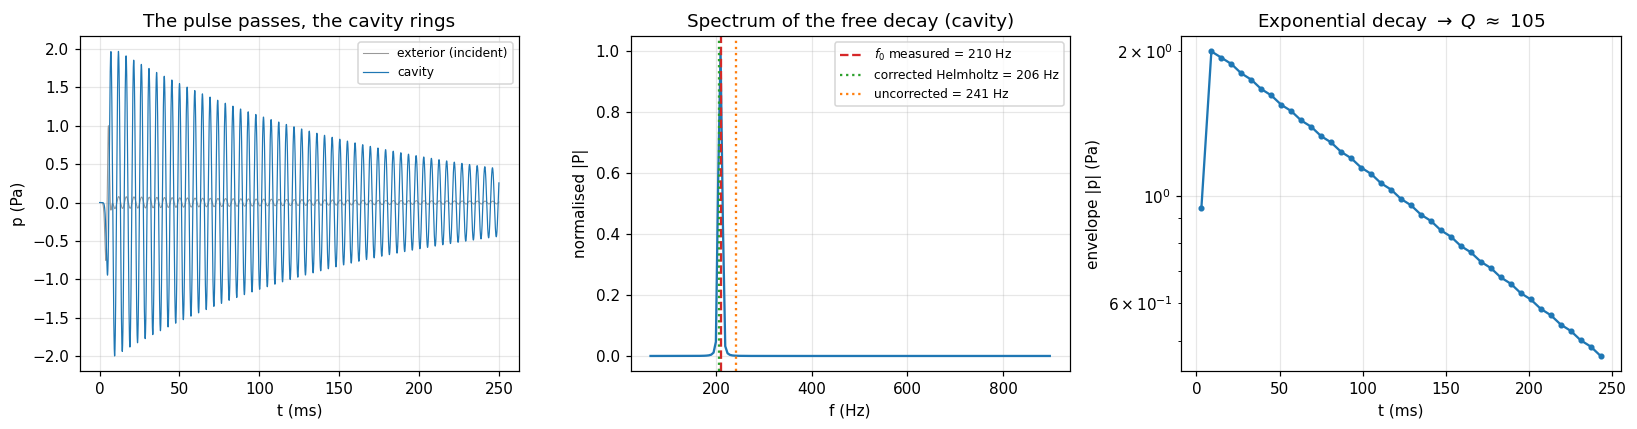

In [3]:
K = 1.0/np.abs(p_out).max()          # normalisation: incident peak = 1 Pa (linear system)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(t*1e3, p_out*K, color='0.6', lw=0.7, label='exterior (incident)')
ax[0].plot(t*1e3, p_cav*K, 'C0', lw=0.8, label='cavity')
ax[0].set(xlabel='t (ms)', ylabel='p (Pa)', title='The pulse passes, the cavity rings')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

band = (freqs > 60) & (freqs < 900)
ax[1].plot(freqs[band], spec[band]/spec[band].max(), 'C0')
ax[1].axvline(f0, color='C3', ls='--', label=f'$f_0$ measured = {f0:.0f} Hz')
ax[1].axvline(f0_cor, color='C2', ls=':', label=f'corrected Helmholtz = {f0_cor:.0f} Hz')
ax[1].axvline(f0_noc, color='C1', ls=':', label=f'uncorrected = {f0_noc:.0f} Hz')
ax[1].set(xlabel='f (Hz)', ylabel='normalised |P|', title='Spectrum of the free decay (cavity)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

k = max(3, int(6e-3/float(d['dt']))); n = len(p_cav)//k
te = np.array([t[i*k:(i+1)*k].mean() for i in range(n)])
ee = np.array([np.abs(p_cav[i*k:(i+1)*k]).max()*K for i in range(n)])
ax[2].semilogy(te*1e3, ee, 'o-', ms=3)
ax[2].set(xlabel='t (ms)', ylabel='envelope |p| (Pa)',
          title=f'Exponential decay $\\rightarrow$ $Q$ $\\approx$ {Q:.0f}')
ax[2].grid(alpha=0.3)
fig.tight_layout(); plt.show()


### Animation

![Helmholtz resonance - open neck](figures/helmholtz_resonance.gif)

*To reproduce the animation:*
```bash
OR_TMS=120 OR_NFRAMES=420 OR_TAG=_anim python src/transient_solver.py
python tools/make_resonance_anim.py
```


## 4. Quantitative verification

The Helmholtz frequency is $f_0=\frac{c}{2\pi}\sqrt{\dfrac{S}{V\,L_{\text{eff}}}}$, with
$S=\pi R_{\text{neck}}^2$, $V=\pi R_{\text{cav}}^2 H_{\text{cav}}$ and $L_{\text{eff}}$ the
**effective** length of the neck -- its geometric length **plus the end corrections**, since air
spills out at both ends of the neck and takes part in the oscillating mass.


In [4]:
S = np.pi*R_NECK**2; V = np.pi*R_CAV**2*H_CAV
f_helm = lambda Leff: C/(2*np.pi)*np.sqrt(S/(V*Leff))
identify = lambda f: S*C**2/(V*(2*np.pi*f)**2)   # effective length INFERRED from a frequency

print(f"f0 measured (simulation, open neck)     : {f0:7.1f} Hz")
print(f"Helmholtz without end correction        : {f0_noc:7.1f} Hz   (deviation {abs(f0_noc-f0)/f0*100:4.1f} %)")
print(f"Helmholtz + corrections (0.85+0.66)R    : {f0_cor:7.1f} Hz   (deviation {abs(f0_cor-f0)/f0*100:4.1f} %)")
print()

# The identification is only as good as the frequency fed into it, and the raw
# h=1 mm value carries the half-cell mesh bias. Both are shown.
f_ext = float(np.load('data/convergence_f0.npz')['f_ext'])
print(f"{'frequency used':<34}{'L_eff (mm)':>12}{'end corr.':>12}")
for name, f in [("raw, h = 1 mm", f0), ("extrapolated to zero mesh", f_ext)]:
    Le = identify(f)
    print(f"{name:<34}{Le*1e3:>12.2f}{(Le-L_NECK)/R_NECK:>10.2f} R")
print(f"{'expected (0.85 exterior + 0.66 interior)':<34}{'':>12}{1.51:>10.2f} R")


f0 measured (simulation, open neck)     :   209.8 Hz
Helmholtz without end correction        :   241.3 Hz   (deviation 15.0 %)
Helmholtz + corrections (0.85+0.66)R    :   205.6 Hz   (deviation  2.0 %)

frequency used                      L_eff (mm)   end corr.
raw, h = 1 mm                            52.92      1.29 R
extrapolated to zero mesh                55.62      1.56 R
expected (0.85 exterior + 0.66 interior)                  1.51 R


**Reading.** The open-neck simulation lands within a few percent of the *corrected* Helmholtz
formula, while it departs by some 15 % from the *uncorrected* one: the exterior mesh **produces**
the end correction instead of assuming it.

The identification of the effective length makes the point sharply. Fed the raw frequency at
h = 1 mm, it returns an end correction of 1.29 R -- 15 % short of the expected 1.51 R, and one
might conclude the exterior mesh underestimates the radiation load. Fed the frequency extrapolated
to zero mesh size, it returns **1.56 R**, within 3 % of the expected value. The apparent
shortfall was the half-cell mesh bias, not physics.

**Damping.** The $Q$ measured here contains **only** radiation losses, since the model is
inviscid. The harmonic study estimates the viscothermal losses of the neck at
$Q_{\text{visc}}\approx47$, which **dominate**: a real resonator would have
$Q^{-1}=Q_{\text{rad}}^{-1}+Q_{\text{visc}}^{-1}$, so $Q\approx32$ -- it would ring more briefly
than this animation suggests. Section 5 shows that the radiation $Q$ computed here is not in fact
converged, which is the reason the project carries an experimental protocol
(`experiments/protocol.md`) to settle the damping by measurement.


In [5]:
Q_visc = 47.0
Q_tot = 1.0/(1.0/Q + 1.0/Q_visc)
print(f"Q radiation (computed here) : {Q:6.1f}")
print(f"Q viscous (harmonic study)  : {Q_visc:6.1f}   <- dominant")
print(f"expected total Q (real)     : {Q_tot:6.1f}")
print(f"associated decay time       : {Q_tot/(np.pi*f0)*1e3:.0f} ms")


Q radiation (computed here) :  105.4
Q viscous (harmonic study)  :   47.0   <- dominant
expected total Q (real)     :   32.5
associated decay time       : 49 ms


## 5. Verification: mesh convergence and sensitivity to the boundaries

Two checks the first version of this notebook omitted -- and they correct one of the results it
announced.


In [6]:
# --- (a) mesh convergence of f0 ---
import pandas as pd
cv = np.load('data/convergence_f0.npz')
display(pd.DataFrame({
    "h (mm)": [f"{x*1e3:.2f}" for x in cv['h']],
    "f0 (Hz, damped-sinusoid fit)": [f"{x:.2f}" for x in cv['f0']],
}))
print(f"observed order         : {float(cv['order']):.3f}")
print(f"f0 extrapolated to h=0 : {float(cv['f_ext']):.2f} Hz   (GCI {float(cv['gci'])*100:.2f} %)")
print(f"corrected Helmholtz    : {float(cv['f_theo']):.2f} Hz")
print(f"deviation              : {abs(float(cv['f_ext'])-float(cv['f_theo']))/float(cv['f_theo'])*100:.2f} %")


,h (mm),"f0 (Hz, damped-sinusoid fit)"
0,2.00,213.06
1,1.00,209.25
2,0.50,207.16


observed order         : 0.863
f0 extrapolated to h=0 : 204.60 Hz   (GCI 1.54 %)
corrected Helmholtz    : 205.56 Hz
deviation              : 0.47 %


The frequency **drifts with the mesh**, and this is not noise: the solver places its walls half
a cell beyond the last node (see `verification/mms_transient.py`), so the geometry actually simulated is
$R+h/2$ and $H+h$. That is a **first-order** bias, and it has to be extrapolated away before the
result is compared with an analytic theory.

> **A result corrected.** The raw value at $h=1$ mm (209.8 Hz) appeared to agree remarkably well
> with the harmonic calculation using a radiation impedance (209.84 Hz). That agreement was
> **fortuitous**: the mesh bias, about +3 % at this resolution, had lifted the value from roughly
> 205 Hz. Once extrapolated, the transient frequency is 204.6 Hz, within 0.47 % of the corrected
> theory. The two numbers originally compared each carried an uncorrected discretisation error.


In [7]:
# --- (b) sensitivity to the absorbing layers and to the domain size ---
sp = np.load('data/sponge_sensitivity.npz', allow_pickle=True)
LABELS = {'sp_base': 'baseline', 'sp_sponge_epais': 'thick sponge',
          'sp_domaine_grand': 'large domain', 'sp_sponge_faible': 'weak absorption'}
display(pd.DataFrame({
    "configuration": [LABELS.get(str(x), str(x)) for x in sp['noms']],
    "L_sponge (m)": sp['L_sp'], "Z_ext (m)": sp['Z_ext'], "sigma factor": sp['sigma'],
    "f0 (Hz)": [f"{x:.1f}" for x in sp['f0']], "Q": [f"{x:.0f}" for x in sp['Q']],
}))
print(f"f0 : total variation {(sp['f0'].max()-sp['f0'].min())/sp['f0'].min()*100:.2f} %")
print(f"Q  : total variation, a factor of {sp['Q'].max()/sp['Q'].min():.1f}")


,configuration,L_sponge (m),Z_ext (m),sigma factor,f0 (Hz),Q
0,baseline,0.03,0.10,5.0,214.6,104
1,thick sponge,0.06,0.13,5.0,214.6,143
2,large domain,0.03,0.18,5.0,214.6,267
3,weak absorption,0.03,0.10,2.0,214.6,44


f0 : total variation 0.00 %
Q  : total variation, a factor of 6.0


**Two opposite conclusions.**

* **$f_0$ is perfectly robust.** It does not move by a tenth of a hertz when the absorbing layer
  is doubled in thickness, when the domain is enlarged, or when the absorption is weakened. The
  natural frequency really is a property of the resonator.

* **$Q$ is not robust at all.** It varies by a **factor of 6** under purely numerical settings.
  The $Q\approx105$ obtained with the reference domain is therefore an **artefact**, not a
  measurement. Enlarging the exterior domain pushes $Q$ towards 267, which approaches the value
  from the harmonic solver -- but without being converged: it keeps growing with the domain size.

In other words, this calculation measures a natural frequency well and a radiation damping badly.
Settling the latter numerically would require a formal PML and a dedicated convergence study;
settling it experimentally is what `experiments/ringdown_analysis.py` is for.


## 6. Limits, stated plainly

* **Sub-wavelength.** At 210 Hz, $\lambda\approx1.6$ m against 12 cm of resonator: the pressure is
  **nearly uniform inside the cavity**. What is seen to propagate is mostly the exterior field and
  the gradient in the neck; the resonance itself is a **lumped** effect -- the mass of air in the
  neck against the stiffness of the cavity -- not a standing wave in the cavity.
* **No viscous losses** in this model, so $Q$ here is not the real $Q$ (section 4).
* **Absorbing layers** rather than a formal PML: residual reflections are small but not zero,
  which affects $Q_{\text{rad}}$ appreciably and $f_0$ very little.
* **An infinite baffle** is assumed. This is consistent with the baffled-piston model used
  elsewhere in the project, but differs from a neck protruding into free air.

## 7. Reproducing this notebook

```bash
python src/transient_solver.py                                          # study (~6 min)
OR_TMS=120 OR_NFRAMES=420 OR_TAG=_anim python src/transient_solver.py   # animation data
python tools/make_resonance_anim.py                                         # -> figures/helmholtz_resonance.gif
python verification/grid_convergence.py                                              # mesh convergence of f0
```
